In [45]:
import numpy as np
import math
import matplotlib.pyplot as plt
import time
from scipy.stats import norm

In [46]:
def gbm_path_sim_vectorized(
    s_start, r, sigma, T_sim, n_sims, m_steps, Z_matrix=None
):
    """
    Simulates Geometric Brownian Motion paths using a vectorized numpy approach.
    
    Can optionally accept a pre-generated matrix of standard normal
    random numbers (Z_matrix) for variance reduction techniques.
    
    s_start: Initial asset price (S_t)
    r: Risk-free interest rate
    sigma: Volatility
    T_sim: Time horizon for the simulation (e.g., T_remaining)
    n_sims: Number of simulation paths (N)
    m_steps: Number of time steps (M_remaining)
    Z_matrix (np.ndarray, optional): A pre-generated (n_sims, m_steps) matrix
                                     of standard normal random numbers.
    """
    
    dt = T_sim / m_steps
    
    # 1. Get the random numbers
    if Z_matrix is None:
        # If no matrix is provided, generate one
        Z = np.random.normal(0.0, 1.0, (n_sims, m_steps))
    else:
        # If a matrix is provided, use it
        # (A good practice check to ensure shapes match)
        if Z_matrix.shape != (n_sims, m_steps):
            raise ValueError(f"Z_matrix shape {Z_matrix.shape} does not match (n_sims, m_steps) {(n_sims, m_steps)}")
        Z = Z_matrix
    
    # 2. Calculate all log-returns in one go
    # Shape: (n_sims, m_steps)
    log_returns = (r - 0.5 * sigma**2) * dt + sigma * math.sqrt(dt) * Z
    
    # 3. Calculate the cumulative sum of log-returns across time (axis=1)
    # Shape: (n_sims, m_steps)
    cumulative_log_returns = np.cumsum(log_returns, axis=1)
    
    # 4. Create the output matrix and set the start price
    # Shape: (n_sims, m_steps + 1)
    simulated_paths = np.zeros((n_sims, m_steps + 1))
    simulated_paths[:, 0] = s_start
    
    # 5. Exponentiate and multiply by s_start to get all prices from t=1 to t=M
    # This fills all columns from index 1 onwards
    simulated_paths[:, 1:] = s_start * np.exp(cumulative_log_returns)
            
    # Return the complete matrix of paths
    return simulated_paths


In [47]:
def price_asian_option_mc_srm(
    s_current, k, r, sigma, T_maturity, n_sims, m_total_steps, omega, 
    t_current=0.0, historical_prices=None, Z_matrix=None
):
    """
    Monte Carlo pricing of an Asian option from time t_current to T_maturity.
    Returns:
      - price: scalar (discounted to t_current)
      - all_future_paths: (n_sims, m_remaining_steps+1) array; column 0 = s_current
                          (when m_remaining_steps == 0, shape is (n_sims, 1) filled with s_current)
      - payoffs: length-n_sims vector of UNdiscounted path payoffs used in the average
    """
    if omega not in (1, -1):
        raise ValueError("omega must be 1 (call) or -1 (put)")

    # 1) Known past up to t_current
    if historical_prices is None or len(historical_prices) == 0:
        sum_known = 0.0
        m_known_steps = 0
    else:
        historical_prices = np.asarray(historical_prices, dtype=float)
        sum_known = float(np.sum(historical_prices))
        m_known_steps = int(len(historical_prices))

    T_remaining = float(T_maturity - t_current)
    m_remaining_steps = int(m_total_steps - m_known_steps)

    # 2) Future paths (or placeholder if none remain)
    if m_remaining_steps > 0:
        all_future_paths = gbm_path_sim_vectorized(
            s_current, r, sigma, T_remaining, n_sims, m_remaining_steps,
            Z_matrix=Z_matrix
        )  # shape: (n_sims, m_remaining_steps+1); col 0 = s_current

        # Drop the start column to sum only future observations
        simulated_future_prices = all_future_paths[:, 1:]                 # (n_sims, m_remaining_steps)
        sum_future = np.sum(simulated_future_prices, axis=1)              # (n_sims,)
        total_sum = sum_known + sum_future                                 # (n_sims,)
        s_ave = total_sum / m_total_steps                                  # (n_sims,)
        payoffs = np.maximum(omega * (s_ave - k), 0.0)                     # UNdiscounted path payoffs
        price = np.mean(payoffs) * np.exp(-r * T_remaining)                # discounted to t_current

    else:
        # No future observations: payoff fully determined by history.
        # Still return arrays with consistent shapes.
        all_future_paths = np.full((n_sims, 1), float(s_current))          # (n_sims, 1)
        s_ave = (sum_known / m_total_steps) * np.ones(n_sims, dtype=float) # (n_sims,)
        payoffs = np.maximum(omega * (s_ave - k), 0.0)                      # UNdiscounted
        # T_remaining == 0 => discount factor = 1.0
        price = float(np.mean(payoffs))

    return price, all_future_paths, payoffs


In [ ]:
# --- 1. Set Parameters ---
s_start = 100
k = 100
r = 0.05
sigma = 0.2
T_maturity = 1.0
n_sims_outer = 10000   
m_steps = 250        
n_sims_inner = 1000
n_ref_paths = 100    # Number of reference paths for SRM
omega = 1            # 1 for a Call option
position = 1         # 1 for LONG


In [49]:
def calculate_srm_weights(target_start_price, ref_start_price, ref_first_step_prices, r, sigma, dt):
    """
    Numerically-stable SRM weights for GBM.
    Uses the closed-form lognormal ratio in log-space:
      w = exp( -((ln y - ln x_i - μ)^2 - (ln y - ln x_r - μ)^2) / (2 σ^2 dt) )
    Then stabilizes by subtracting max(logw); self-normalization later removes the scale.
    """
    y = np.asarray(ref_first_step_prices, dtype=float)
    x_i = float(target_start_price)
    x_r = float(ref_start_price)

    # Guard against zeros (purely defensive; realistic GBM paths are > 0)
    eps = 1e-300
    y = np.maximum(y, eps)
    x_i = max(x_i, eps)
    x_r = max(x_r, eps)

    v = (sigma ** 2) * dt                       # variance term
    mu = (r - 0.5 * sigma ** 2) * dt            # drift term over dt

    a = np.log(y) - np.log(x_i) - mu            # numerator for target
    b = np.log(y) - np.log(x_r) - mu            # numerator for reference

    logw = - (a * a - b * b) / (2.0 * v)        # stable quadratic form
    logw -= np.max(logw)                        # stabilize exponentials
    w = np.exp(logw)                            # unnormalized weights

    return w


In [50]:
def calculate_mtm_matrix_asian_srm(
    all_paths: np.ndarray,
    k: float,
    r: float,
    sigma: float,
    T_maturity: float,
    omega: int,
    n_sims_inner: int,
    n_ref_paths: int
):
    """
    Builds the MtM matrix for an Asian option using SRM.
    - References chosen by S_t quantiles at each slice.
    - Inner simulated once per reference; cache first-step and sum of future prices.
    - For each target, recompute the Asian payoff using the target's own history
      on the SAME future paths, then self-normalize the SRM weights.
    """
    n_sims_outer, m_steps_plus_1 = all_paths.shape
    m_steps = m_steps_plus_1 - 1
    mtm_matrix = np.zeros_like(all_paths, dtype=float)
    time_vector = np.linspace(0.0, T_maturity, m_steps + 1)

    print(f"Calculating Asian MtM matrix (SRM, outer={n_sims_outer}, refs={n_ref_paths})...")
    t0 = time.time()

    for j in range(m_steps + 1):
        t_current = time_vector[j]
        m_known_steps = j
        m_remaining_steps = m_steps - m_known_steps
        T_remaining = T_maturity - t_current

        if j % 20 == 0 or j == m_steps:
            print(f"  Pricing time step {j}/{m_steps}...")

        # Maturity: payoff from full history (no discount)
        if m_remaining_steps <= 0:
            hist_prices = all_paths[:, 1:j+1]
            s_ave = np.mean(hist_prices, axis=1)
            payoffs = np.maximum(omega * (s_ave - k), 0.0)
            mtm_matrix[:, j] = payoffs
            continue

        # References by S_t quantiles
        s_slice = all_paths[:, j]
        order = np.argsort(s_slice)
        pick = np.linspace(0, n_sims_outer - 1, n_ref_paths).astype(int)
        ref_indices = order[pick]
        ref_start_prices = all_paths[ref_indices, j]

        # Inner once per reference; cache for recycling
        ref_cache = {}
        for idx_in_list, i_ref in enumerate(ref_indices):
            s_current_ref = ref_start_prices[idx_in_list]
            hist_prices_ref = all_paths[i_ref, 1:j+1]

            price_ref, future_paths_ref, _ = price_asian_option_mc_srm(
                s_current=s_current_ref, k=k, r=r, sigma=sigma,
                T_maturity=T_maturity, n_sims=n_sims_inner,
                m_total_steps=m_steps, omega=omega,
                t_current=t_current, historical_prices=hist_prices_ref
            )
            mtm_matrix[i_ref, j] = price_ref

            # future_paths_ref: (n_inner, m_remaining_steps+1), col 0 = s_current_ref, col 1 = first step
            first_step = future_paths_ref[:, 1]                       # y_j
            sum_future = np.sum(future_paths_ref[:, 1:], axis=1)      # Σ future prices per inner path

            ref_cache[i_ref] = {
                "first_step": first_step,         # (n_inner,)
                "sum_future": sum_future,         # (n_inner,)
                "s_start": float(s_current_ref)   # scalar
            }

        # Recycle to each target
        dt_inner = T_remaining / m_remaining_steps

        for i in range(n_sims_outer):
            if i in ref_indices:
                continue

            s_current_i = all_paths[i, j]

            # nearest reference (by |S_t - S_ref|)
            nearest_ref_idx = int(np.argmin(np.abs(ref_start_prices - s_current_i)))
            i_ref = int(ref_indices[nearest_ref_idx])
            cache = ref_cache[i_ref]

            # Stable weights for the first inner step
            w = calculate_srm_weights(
                target_start_price=s_current_i,
                ref_start_price=cache["s_start"],
                ref_first_step_prices=cache["first_step"],
                r=r, sigma=sigma, dt=dt_inner
            )

            # Recompute Asian payoff for THIS target's past on the SAME future paths
            sum_future = cache["sum_future"]
            sum_known_i = float(np.sum(all_paths[i, 1:j+1]))
            s_ave_i = (sum_known_i + sum_future) / m_steps
            payoffs_target = np.maximum(omega * (s_ave_i - k), 0.0)   # UNdiscounted

            # Self-normalized IS (prevents bias from numerical scaling)
            wsum = np.sum(w)
            if wsum <= 0.0 or not np.isfinite(wsum):
                # emergency fallback: uniform weights
                price_i = float(np.mean(payoffs_target)) * np.exp(-r * T_remaining)
            else:
                price_i = float(np.dot(w, payoffs_target) / wsum) * np.exp(-r * T_remaining)

            mtm_matrix[i, j] = price_i

    print(f"Asian (SRM) MtM calculation complete. Took {time.time() - t0:.2f} seconds.")
    return mtm_matrix, time_vector


In [51]:
print("\nStep 1: Simulating all 'outer' paths ...")
start_time = time.time()


all_paths = gbm_path_sim_vectorized(
    s_start, r, sigma, T_maturity, n_sims_outer, m_steps
)
mtm_matrix_asian_srm, time_vector = calculate_mtm_matrix_asian_srm(
    all_paths=all_paths, k=k, r=r, sigma=sigma,
    T_maturity=T_maturity, omega=omega, 
    n_sims_inner=n_sims_inner, n_ref_paths=n_ref_paths
)

end_time = time.time()
print(f"GBM path simulation complete. Took {end_time - start_time:.4f} seconds.")

mtm_final_asian_srm = mtm_matrix_asian_srm * position
x_asian_srm = np.maximum(mtm_final_asian_srm, 0)
ee_profile_asian_srm = np.mean(x_asian_srm, axis=0)
se_profile_asian_srm = x_asian_srm.std(axis=0, ddof=1) / np.sqrt(max(n_sims_outer, 1))
pfe_profile_asian_srm = np.quantile(np.maximum(mtm_final_asian_srm, 0), 0.95, axis=0)


Step 1: Simulating all 'outer' paths ...
Calculating Asian MtM matrix (SRM, outer=10000, refs=100)...
  Pricing time step 0/250...
  Pricing time step 20/250...
  Pricing time step 40/250...
  Pricing time step 60/250...
  Pricing time step 80/250...
  Pricing time step 100/250...
  Pricing time step 120/250...
  Pricing time step 140/250...
  Pricing time step 160/250...
  Pricing time step 180/250...
  Pricing time step 200/250...
  Pricing time step 220/250...
  Pricing time step 240/250...
  Pricing time step 250/250...
Asian (SRM) MtM calculation complete. Took 166.28 seconds.
GBM path simulation complete. Took 166.3609 seconds.


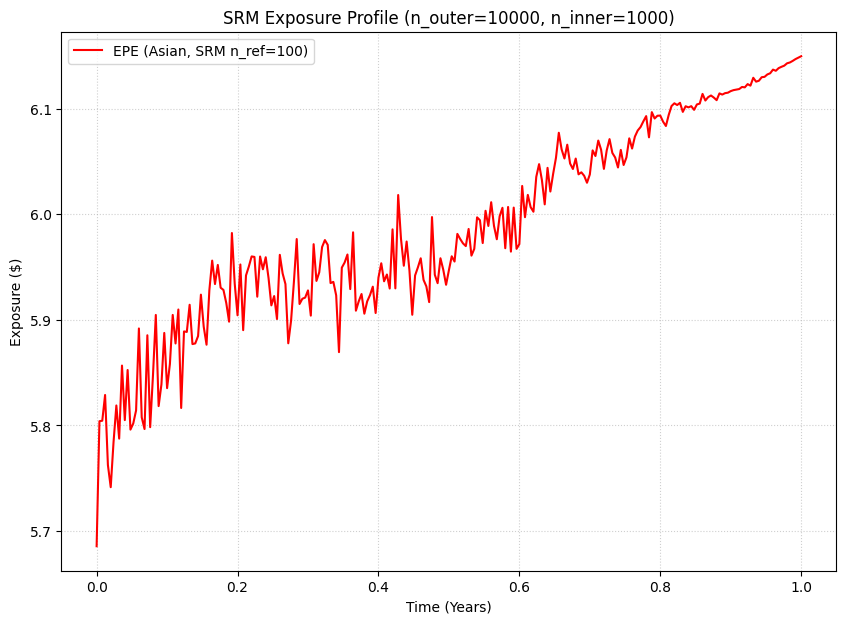

In [52]:
plt.figure(figsize=(10, 7))

plt.plot(time_vector, ee_profile_asian_srm, label=f"EPE (Asian, SRM n_ref={n_ref_paths})", color="red")

plt.title(f"SRM Exposure Profile (n_outer={n_sims_outer}, n_inner={n_sims_inner})")
plt.xlabel("Time (Years)")
plt.ylabel("Exposure ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

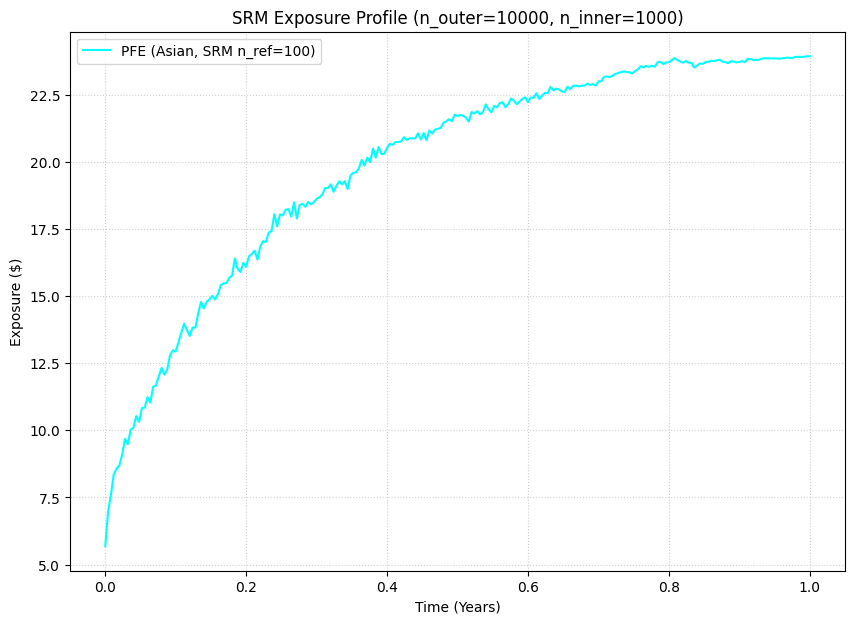

In [53]:
plt.figure(figsize=(10, 7))

plt.plot(time_vector, pfe_profile_asian_srm, label=f"PFE (Asian, SRM n_ref={n_ref_paths})", color="cyan")

plt.title(f"SRM Exposure Profile (n_outer={n_sims_outer}, n_inner={n_sims_inner})")
plt.xlabel("Time (Years)")
plt.ylabel("Exposure ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)


[Plot saved to 'srm_exposure_plot.png']


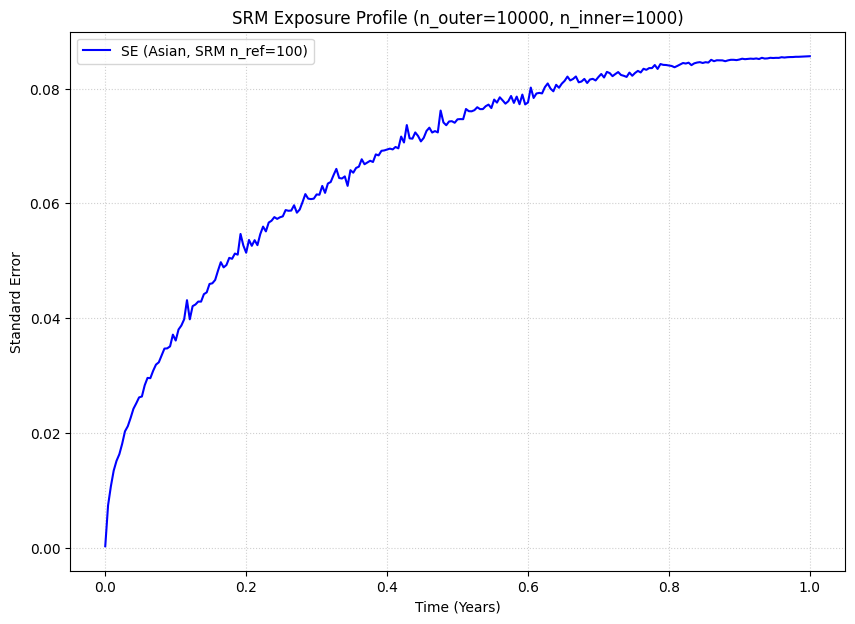

In [54]:
plt.figure(figsize=(10, 7))
    
plt.plot(time_vector, se_profile_asian_srm, label=f"SE (Asian, SRM n_ref={n_ref_paths})", color="blue")

plt.title(f"SRM Exposure Profile (n_outer={n_sims_outer}, n_inner={n_sims_inner})")
plt.xlabel("Time (Years)")
plt.ylabel("Standard Error")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.savefig("srm_exposure_plot.png")
print("\n[Plot saved to 'srm_exposure_plot.png']")